# Gold Simulation Notebook Using Saved `seed_2` Artifacts

This notebook is for **simulation / inference only**.

It keeps the original reported test result unchanged and uses the saved model artifacts to simulate on **later unseen data**. It follows this workflow:

1. Keep the original reported test result unchanged.
2. Load the later-data CSV.
3. Load the saved `seed_2` model artifacts.
4. Reuse the exact saved scalers.
5. Reuse the feature order and lookback from metadata.
6. Combine original history + later data for lookback context.
7. Build a dated prediction table.
8. Compute later-period simulation metrics.
9. Plot actual vs predicted for the simulation window.
10. Let the user type a forecast date and return the matching forecast row.

**Important:** this notebook mirrors the saved training/inference setup. It does **not** retrain the model and does **not** fit new scalers.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip -q install tensorflow scikit-learn pandas numpy matplotlib


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1) User paths and simulation settings

These paths use the locations you provided.  
The original historical path below is filled from the uploaded training notebook and is only used to provide lookback context before the later simulation period.


In [ ]:
import os

# =========================
# Paths you provided
# =========================
BASE_DIR = r"/content/drive/MyDrive/Silver gold Research/Silver gold/ CleanDATA_2026_interpolate/silver_interpolated_plus2_all_seed_models_improved_1cnn_1bilstm(10pm)_norma/seed_0"
NEW_DATA_PATH = r"/content/drive/MyDrive/IPYNB SIMULATION/CleanDATA_2025_05_01_to_2025_12_01_gold_silver_tables_only/silver_RRL_interpolate.csv"

MODEL_METADATA_PATH = os.path.join(BASE_DIR, "model_metadata.pkl")
MODEL_PATH = os.path.join(BASE_DIR, "cnn_bilstm_seed0.keras")
X_SCALER_PATH = os.path.join(BASE_DIR, "x_scaler.pkl")
Y_SCALER_PATH = os.path.join(BASE_DIR, "y_scaler.pkl")

# =========================
# Original historical file used for lookback context
# This path is taken from the uploaded training notebook.
# Change this only if your original cleaned historical file is stored elsewhere.
# =========================
ORIGINAL_HISTORY_PATH = r"/content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026_study_aligned/silver_RRL_interpolate_plus2.csv"

# =========================
# Dataset settings
# =========================
DATE_COL = "Date"
RAW_TARGET_COL = "Silver_Futures"

# Later-period simulation window
SIM_START = "2025-05-01"
SIM_END = "2025-11-28"

# Default example query date for the date-lookup step
DEFAULT_QUERY_DATE = "2025-08-15"

# Optional export folder for simulation outputs
SIM_OUTPUT_DIR = os.path.join(BASE_DIR, "simulation_outputs")
os.makedirs(SIM_OUTPUT_DIR, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("NEW_DATA_PATH:", NEW_DATA_PATH)
print("ORIGINAL_HISTORY_PATH:", ORIGINAL_HISTORY_PATH)
print("SIM_OUTPUT_DIR:", SIM_OUTPUT_DIR)


BASE_DIR: /content/drive/MyDrive/Silver gold Research/Silver gold/ CleanDATA_2026_interpolate/silver_interpolated_plus2_all_seed_models_improved_1cnn_1bilstm(10pm)_norma/seed_0
NEW_DATA_PATH: /content/drive/MyDrive/IPYNB SIMULATION/CleanDATA_2025_05_01_to_2025_12_01_gold_silver_tables_only/silver_RRL_interpolate.csv
ORIGINAL_HISTORY_PATH: /content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026_study_aligned/silver_RRL_interpolate_plus2.csv
SIM_OUTPUT_DIR: /content/drive/MyDrive/Silver gold Research/Silver gold/ CleanDATA_2026_interpolate/silver_interpolated_plus2_all_seed_models_improved_1cnn_1bilstm(10pm)_norma/seed_0/simulation_outputs


## 2) Imports

In [ ]:
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## 3) Helper functions

These helpers are written to stay consistent with the saved training pipeline:

- load the saved model and scalers
- reuse `feature_cols`, `target_col`, and `lookback` from metadata
- build sequences the same way as the saved notebook did
- create a dated prediction table for simulation


In [ ]:
def validate_paths(paths_dict):
    missing = [name for name, path in paths_dict.items() if not os.path.exists(path)]
    if missing:
        raise FileNotFoundError(
            "These required files were not found:\n" +
            "\n".join([f"- {name}: {paths_dict[name]}" for name in missing])
        )
    print("All required files were found.")


def load_artifacts_from_explicit_paths(
    model_metadata_path,
    model_path,
    x_scaler_path,
    y_scaler_path,
):
    with open(model_metadata_path, "rb") as f:
        metadata = pickle.load(f)

    model = tf.keras.models.load_model(model_path)

    with open(x_scaler_path, "rb") as f:
        x_scaler = pickle.load(f)

    y_scaler = None
    if os.path.exists(y_scaler_path):
        with open(y_scaler_path, "rb") as f:
            y_scaler = pickle.load(f)

    return model, x_scaler, y_scaler, metadata


def create_sequences_exact_training_style(X_df, y_df, lookback):
    """
    This mirrors the saved training notebook exactly.
    It is intentionally kept consistent with the artifact-generating notebook.
    """
    X_values = X_df.values
    y_values = y_df.values.reshape(-1)

    X_seq, y_seq = [], []
    for i in range(lookback, len(X_df)):
        X_seq.append(X_values[i - lookback:i, :])
        y_seq.append(y_values[i])

    return np.array(X_seq), np.array(y_seq)


def load_and_prepare_raw_dataframe(csv_path, date_col):
    df = pd.read_csv(csv_path)

    if date_col not in df.columns:
        raise ValueError(f"'{date_col}' is not present in: {csv_path}")

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)
    return df


def build_simulation_results_table(
    historical_df,
    new_df,
    metadata,
    x_scaler,
    y_scaler,
    model,
    date_col,
    raw_target_col,
):
    feature_cols = list(metadata["feature_cols"])
    model_target_col = metadata["target_col"]
    lookback = int(metadata["lookback"])

    required_cols = [date_col] + feature_cols
    if raw_target_col not in required_cols:
        required_cols.append(raw_target_col)

    hist = historical_df[required_cols].copy()
    new = new_df[required_cols].copy()

    full_df = pd.concat([hist, new], ignore_index=True)
    full_df = (
        full_df
        .drop_duplicates(subset=[date_col], keep="last")
        .sort_values(date_col)
        .reset_index(drop=True)
    )

    # Build the shifted target and the true future date before dropping rows
    full_df["forecast_date"] = full_df[date_col].shift(-1)
    full_df[model_target_col] = pd.to_numeric(full_df[raw_target_col], errors="coerce").shift(-1)

    numeric_needed = list(dict.fromkeys(feature_cols + [raw_target_col, model_target_col]))
    for col in numeric_needed:
        full_df[col] = pd.to_numeric(full_df[col], errors="coerce")

    full_df = full_df.replace([np.inf, -np.inf], np.nan)

    # Keep only rows that can actually be used for prediction/evaluation
    full_df = full_df.dropna(subset=feature_cols + [model_target_col, "forecast_date"]).reset_index(drop=True)

    if len(full_df) <= lookback:
        raise ValueError(
            f"Not enough rows after cleaning to create sequences. "
            f"Rows available: {len(full_df)}, lookback: {lookback}"
        )

    X_scaled = pd.DataFrame(
        x_scaler.transform(full_df[feature_cols]),
        columns=feature_cols
    )

    if y_scaler is not None:
        y_scaled = pd.DataFrame(
            y_scaler.transform(full_df[[model_target_col]]),
            columns=[model_target_col]
        )
    else:
        y_scaled = full_df[[model_target_col]].copy()

    X_seq, y_seq = create_sequences_exact_training_style(X_scaled, y_scaled, lookback)

    pred_scaled = model.predict(X_seq, verbose=0).reshape(-1, 1)

    if y_scaler is not None:
        predicted_price = y_scaler.inverse_transform(pred_scaled).reshape(-1)
        actual_price = y_scaler.inverse_transform(y_seq.reshape(-1, 1)).reshape(-1)
    else:
        predicted_price = pred_scaled.reshape(-1)
        actual_price = y_seq.reshape(-1)

    results = pd.DataFrame({
        # This anchor_date follows the row that owns target_t_plus_1
        # to stay consistent with the saved training pipeline.
        "anchor_date": full_df[date_col].iloc[lookback:].reset_index(drop=True),
        "forecast_date": full_df["forecast_date"].iloc[lookback:].reset_index(drop=True),
        "predicted_price": predicted_price,
        "actual_price": actual_price,
    })

    return results, full_df


def evaluate_simulation_window(results_df, sim_start, sim_end):
    sim_start = pd.Timestamp(sim_start)
    sim_end = pd.Timestamp(sim_end)

    sim_results = results_df[
        (results_df["forecast_date"] >= sim_start) &
        (results_df["forecast_date"] <= sim_end)
    ].copy()

    if sim_results.empty:
        raise ValueError("No simulation rows were found inside the selected simulation window.")

    rmse = np.sqrt(mean_squared_error(sim_results["actual_price"], sim_results["predicted_price"]))
    mae = mean_absolute_error(sim_results["actual_price"], sim_results["predicted_price"])
    r2 = r2_score(sim_results["actual_price"], sim_results["predicted_price"])

    metrics = {
        "rows": int(len(sim_results)),
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
    }

    return sim_results, metrics


def lookup_forecast_by_date(results_df, query_date):
    q = pd.Timestamp(query_date)
    out = results_df[results_df["forecast_date"] == q].copy()
    return out


def nearest_available_dates(results_df, query_date, n=5):
    q = pd.Timestamp(query_date)
    tmp = results_df.copy()
    tmp["abs_days_diff"] = (tmp["forecast_date"] - q).abs().dt.days
    return tmp.sort_values(["abs_days_diff", "forecast_date"]).head(n)[
        ["anchor_date", "forecast_date", "predicted_price", "actual_price"]
    ]


## 4) Check files and load the saved artifacts

This keeps the original benchmark unchanged and only reads the saved artifacts.


In [ ]:
validate_paths({
    "MODEL_METADATA_PATH": MODEL_METADATA_PATH,
    "MODEL_PATH": MODEL_PATH,
    "X_SCALER_PATH": X_SCALER_PATH,
    "Y_SCALER_PATH": Y_SCALER_PATH,
    "NEW_DATA_PATH": NEW_DATA_PATH,
    "ORIGINAL_HISTORY_PATH": ORIGINAL_HISTORY_PATH,
})

model, x_scaler, y_scaler, metadata = load_artifacts_from_explicit_paths(
    MODEL_METADATA_PATH,
    MODEL_PATH,
    X_SCALER_PATH,
    Y_SCALER_PATH,
)

print("Loaded metadata:")
print(json.dumps({
    "seed": metadata.get("seed"),
    "horizon": metadata.get("horizon"),
    "lookback": metadata.get("lookback"),
    "target_col": metadata.get("target_col"),
    "model_file": metadata.get("model_file"),
    "has_y_scaler": metadata.get("has_y_scaler"),
    "best_epoch": metadata.get("best_epoch"),
    "rmse_test": metadata.get("rmse_test"),
    "r2_test": metadata.get("r2_test"),
    "num_features": len(metadata.get("feature_cols", [])),
}, indent=4))

print("\nFeature columns used by the saved model:")
print(metadata["feature_cols"])


All required files were found.
Loaded metadata:
{
    "seed": 0,
    "horizon": 1,
    "lookback": 12,
    "target_col": "target_t_plus_1",
    "model_file": "cnn_bilstm_seed0.keras",
    "has_y_scaler": true,
    "best_epoch": 12,
    "rmse_test": 1.207875517702614,
    "r2_test": 0.9037322878572354,
    "num_features": 8
}

Feature columns used by the saved model:
['Silver_Futures', 'Gold_Futures', 'US30', 'SnP500', 'NASDAQ_100', 'USD_index', 'T10Y2Y', 'IGREA']


## 5) Show the official benchmark from the saved metadata

This is the original reported test result from the saved seed model.  
It is shown here for reference and is **not** recomputed or modified.


In [ ]:
official_benchmark = pd.DataFrame([{
    "seed": metadata.get("seed"),
    "best_epoch": metadata.get("best_epoch"),
    "official_test_rmse": metadata.get("rmse_test"),
    "official_test_r2": metadata.get("r2_test"),
    "lookback": metadata.get("lookback"),
    "num_features": len(metadata.get("feature_cols", [])),
    "model_file": metadata.get("model_file"),
}])

display(official_benchmark)


,seed,best_epoch,official_test_rmse,official_test_r2,lookback,num_features,model_file
0,0,12,1.207876,0.903732,12,8,cnn_bilstm_seed0.keras


## 6) Load the original historical file and the later data file

- The original historical file provides the context rows needed by the rolling lookback.
- The later file provides the unseen dates for the simulation period.


In [ ]:
historical_df = load_and_prepare_raw_dataframe(ORIGINAL_HISTORY_PATH, DATE_COL)
new_df = load_and_prepare_raw_dataframe(NEW_DATA_PATH, DATE_COL)

print("Historical dataframe shape:", historical_df.shape)
print("Historical date range:", historical_df[DATE_COL].min(), "to", historical_df[DATE_COL].max())
print()
print("New later-data dataframe shape:", new_df.shape)
print("New later-data date range:", new_df[DATE_COL].min(), "to", new_df[DATE_COL].max())

display(historical_df.head())
display(new_df.head())


Historical dataframe shape: (2546, 9)
Historical date range: 2015-04-01 00:00:00 to 2025-04-30 00:00:00

New later-data dataframe shape: (148, 9)
New later-data date range: 2025-05-01 00:00:00 to 2025-11-28 00:00:00


,Date,Silver_Futures,Gold_Futures,US30,SnP500,NASDAQ_100,USD_index,T10Y2Y,IGREA
0,2015-04-01,17.059,1208.2,17698.2,2059.7,4311.26,98.190002,1.32,-96.726032
1,2015-04-02,16.701,1200.9,17763.2,2067.0,4316.01,97.440002,1.37,-96.699724
2,2015-04-06,17.110,1218.6,17880.8,2080.6,4350.98,97.110001,1.41,-96.594492
3,2015-04-07,16.840,1210.6,17875.4,2076.3,4344.08,97.830002,1.37,-96.568184
4,2015-04-08,16.454,1203.1,17902.5,2081.9,4375.96,98.070000,1.38,-96.541876


,Date,Silver_Futures,Gold_Futures,US30,SnP500,NASDAQ_100,USD_index,T10Y2Y,IGREA
0,2025-05-01,32.469,3222.200000,40717.0,5604.14,19786.71,100.14,0.55,-25.047849
1,2025-05-02,31.989,3231.899902,41332.0,5686.67,20102.61,100.04,0.50,-24.314511
2,2025-05-05,32.474,3322.300000,41214.5,5650.38,19967.94,99.79,0.53,-22.114497
3,2025-05-06,33.381,3422.800000,41107.5,5606.91,19791.35,99.61,0.52,-21.381159
4,2025-05-07,32.791,3391.900000,41075.5,5631.28,19867.97,99.87,0.48,-20.647821


## 7) Build the dated prediction table

This step:

- combines original history + later data
- keeps the exact feature order from metadata
- uses the saved scaler instead of fitting a new one
- predicts with the saved model
- builds a results table with:
  - `anchor_date`
  - `forecast_date`
  - `predicted_price`
  - `actual_price`


In [ ]:
results_df, combined_work_df = build_simulation_results_table(
    historical_df=historical_df,
    new_df=new_df,
    metadata=metadata,
    x_scaler=x_scaler,
    y_scaler=y_scaler,
    model=model,
    date_col=DATE_COL,
    raw_target_col=RAW_TARGET_COL,
)

print("Combined cleaned dataframe used for inference:", combined_work_df.shape)
print("Full prediction table shape:", results_df.shape)
print("Prediction table forecast range:", results_df["forecast_date"].min(), "to", results_df["forecast_date"].max())

display(results_df.head(10))
display(results_df.tail(10))


Combined cleaned dataframe used for inference: (2693, 11)
Full prediction table shape: (2681, 4)
Prediction table forecast range: 2015-04-21 00:00:00 to 2025-11-28 00:00:00


,anchor_date,forecast_date,predicted_price,actual_price
0,2015-04-20,2015-04-21,15.577859,16.008
1,2015-04-21,2015-04-22,15.478086,15.796
2,2015-04-22,2015-04-23,15.417898,15.829
3,2015-04-23,2015-04-24,15.296302,15.636
4,2015-04-24,2015-04-27,15.241987,16.394
5,2015-04-27,2015-04-28,15.186090,16.591
6,2015-04-28,2015-04-29,15.276315,16.702
7,2015-04-29,2015-04-30,15.380574,16.153
8,2015-04-30,2015-05-01,15.475191,16.135
9,2015-05-01,2015-05-04,15.484855,16.441


,anchor_date,forecast_date,predicted_price,actual_price
2671,2025-11-13,2025-11-14,47.923393,50.590000
2672,2025-11-14,2025-11-17,47.926624,50.521000
2673,2025-11-17,2025-11-18,48.050888,50.854000
2674,2025-11-18,2025-11-19,48.077099,50.301000
2675,2025-11-19,2025-11-20,48.201748,49.913000
2676,2025-11-20,2025-11-21,48.260326,49.873001
2677,2025-11-21,2025-11-24,48.296074,50.965000
2678,2025-11-24,2025-11-25,48.332375,53.607000
2679,2025-11-25,2025-11-26,48.558578,57.163000
2680,2025-11-26,2025-11-28,48.742901,56.445999


## 8) Filter to the later simulation period and compute metrics

This keeps the official benchmark unchanged and separately evaluates the later unseen period.


In [ ]:
sim_results, sim_metrics = evaluate_simulation_window(
    results_df=results_df,
    sim_start=SIM_START,
    sim_end=SIM_END,
)

print("Later-period simulation metrics:")
print(json.dumps(sim_metrics, indent=4))

metrics_df = pd.DataFrame([sim_metrics])
display(metrics_df)

display(sim_results.head())
display(sim_results.tail())


Later-period simulation metrics:
{
    "rows": 148,
    "rmse": 2.5034995844441035,
    "mae": 1.9993926334896606,
    "r2": 0.8408804036102052
}


,rows,rmse,mae,r2
0,148,2.5035,1.999393,0.84088


,anchor_date,forecast_date,predicted_price,actual_price
2533,2025-04-30,2025-05-01,36.368664,32.469
2534,2025-05-01,2025-05-02,36.465347,31.989
2535,2025-05-02,2025-05-05,36.458603,32.474
2536,2025-05-05,2025-05-06,36.497993,33.381
2537,2025-05-06,2025-05-07,36.447018,32.791


,anchor_date,forecast_date,predicted_price,actual_price
2676,2025-11-20,2025-11-21,48.260326,49.873001
2677,2025-11-21,2025-11-24,48.296074,50.965000
2678,2025-11-24,2025-11-25,48.332375,53.607000
2679,2025-11-25,2025-11-26,48.558578,57.163000
2680,2025-11-26,2025-11-28,48.742901,56.445999


## 9) Plot actual vs predicted for the simulation window

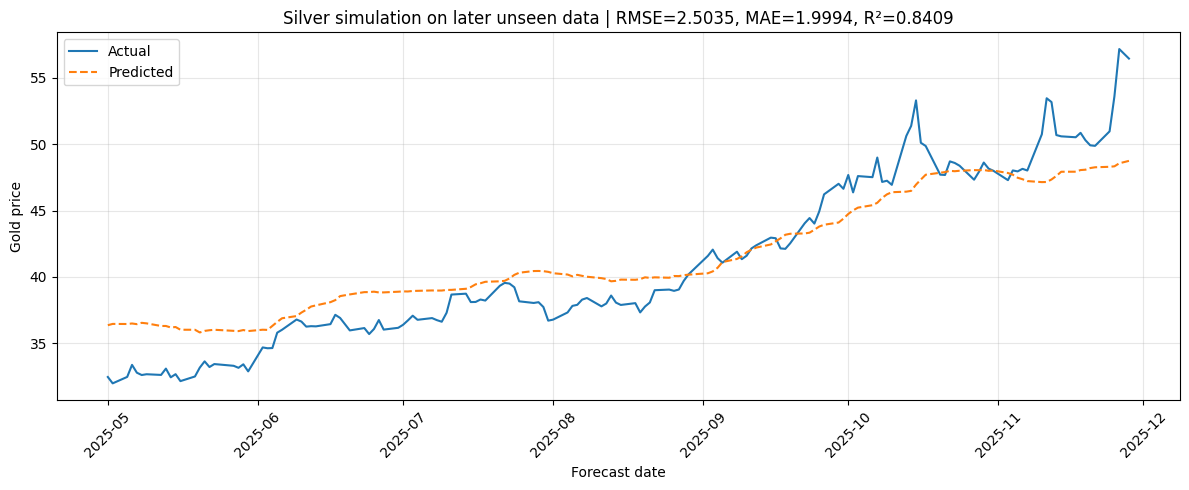

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(sim_results["forecast_date"], sim_results["actual_price"], label="Actual")
plt.plot(sim_results["forecast_date"], sim_results["predicted_price"], linestyle="--", label="Predicted")
plt.title(
    f"Silver simulation on later unseen data | "
    f"RMSE={sim_metrics['rmse']:.4f}, MAE={sim_metrics['mae']:.4f}, R²={sim_metrics['r2']:.4f}"
)
plt.xlabel("Forecast date")
plt.ylabel("Gold price")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 10) Save the simulation outputs

This exports the later-period prediction table and the metrics for reporting or thesis appendices.


In [ ]:
simulation_csv_path = os.path.join(SIM_OUTPUT_DIR, "silver_seed0_simulation_results_2025_05_01_to_2025_11_28.csv")
metrics_json_path = os.path.join(SIM_OUTPUT_DIR, "silver_seed0_simulation_metrics_2025_05_01_to_2025_11_28.json")

sim_results.to_csv(simulation_csv_path, index=False)

with open(metrics_json_path, "w", encoding="utf-8") as f:
    json.dump(sim_metrics, f, indent=4)

print("Saved simulation table to:", simulation_csv_path)
print("Saved simulation metrics to:", metrics_json_path)


Saved simulation table to: /content/drive/MyDrive/Silver gold Research/Silver gold/ CleanDATA_2026_interpolate/silver_interpolated_plus2_all_seed_models_improved_1cnn_1bilstm(10pm)_norma/seed_0/simulation_outputs/silver_seed0_simulation_results_2025_05_01_to_2025_11_28.csv
Saved simulation metrics to: /content/drive/MyDrive/Silver gold Research/Silver gold/ CleanDATA_2026_interpolate/silver_interpolated_plus2_all_seed_models_improved_1cnn_1bilstm(10pm)_norma/seed_0/simulation_outputs/silver_seed0_simulation_metrics_2025_05_01_to_2025_11_28.json


## 11) User-input date lookup

This is the date-query simulation step.

Enter a `forecast_date` that exists in the results table.  
If the date is not available, the notebook will show the nearest available forecast dates.


In [ ]:
query_date = input(f"Enter the forecast date you want to inspect [default: {DEFAULT_QUERY_DATE}]: ").strip()
if query_date == "":
    query_date = DEFAULT_QUERY_DATE

picked = lookup_forecast_by_date(results_df, query_date)

if picked.empty:
    print(f"No exact forecast row was found for {pd.Timestamp(query_date).date()}.")
    print("\nNearest available forecast dates:")
    display(nearest_available_dates(results_df, query_date, n=10))
else:
    print(f"Forecast row for {pd.Timestamp(query_date).date()}:")
    display(picked)


Enter the forecast date you want to inspect [default: 2025-08-15]: 2025-06-03
Forecast row for 2025-06-03:


,anchor_date,forecast_date,predicted_price,actual_price
2555,2025-06-02,2025-06-03,36.014221,34.633


## 12) Optional thesis/demo note

For a stronger demo later, you can repeat the same notebook across all saved seed folders and average the predictions.  
This notebook uses **one saved seed (`seed_2`)** only, because that is the artifact path you supplied.
